# ME 144/244: Modeling, Simulation, and Digital Twins of Drone-Based Systems 
## Project 3: Swarm
## Spring 2026 Semester
### GSI - Tommy Hosmer

## Notebook to generate figures

In [1]:
import pickle
from simulation import Simulation
from animation import Animation
from swarmga import SwarmGA

## Load the parameter values that define the GA and Simulation

In [2]:
with open('parameters.pkl', 'rb') as file:
    parameters = pickle.load(file)

# Run GA

In [3]:
swarmGA = SwarmGA(parameters)
swarmGA.initialize_special_params()
# Return dictionary of results
data = swarmGA.specialGA(print_statements=True)

Generation: 1
Best cost: 20.166666666666668
M*: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0.]
T*: [0.01666667 0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.     

## Dump GA results into a pickle file

### This allows you to reuse data from the GA in the event you restart the notebook. With the data saved you can simply read the pkl and run the animations/plots when convenient

In [4]:
with open('ga_results.pkl', 'wb') as f:
        pickle.dump(data, f)

# Run Simulation with GA Results


In [5]:
# Run this cell in case of kernel restart and need GA data from pickle file
with open('ga_results.pkl', 'rb') as file:
    data = pickle.load(file)

In [6]:
LAM = data['best_p_strings'][0]
sim = Simulation(parameters=parameters, path_to_genes='')
PI, posData, tarData, obsData, counter, Mstar, Tstar, Lstar =  sim.run_simulation(True, LAM)

# Make Plots and Animations

In [7]:
animationObject = Animation(counter, tarData, posData, obsData, parameters)

# Question 1

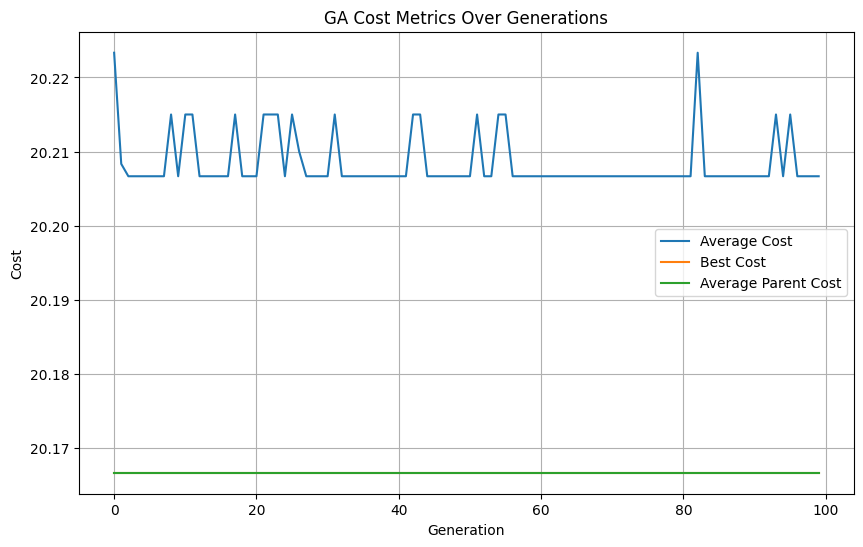

In [12]:
animationObject.plot_costs_over_generations('ga_results.pkl','figures')

## Question 2

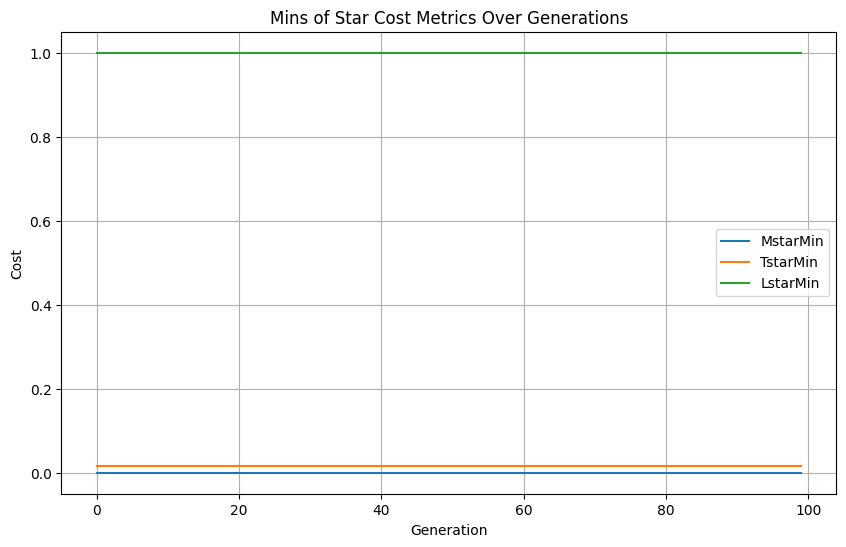

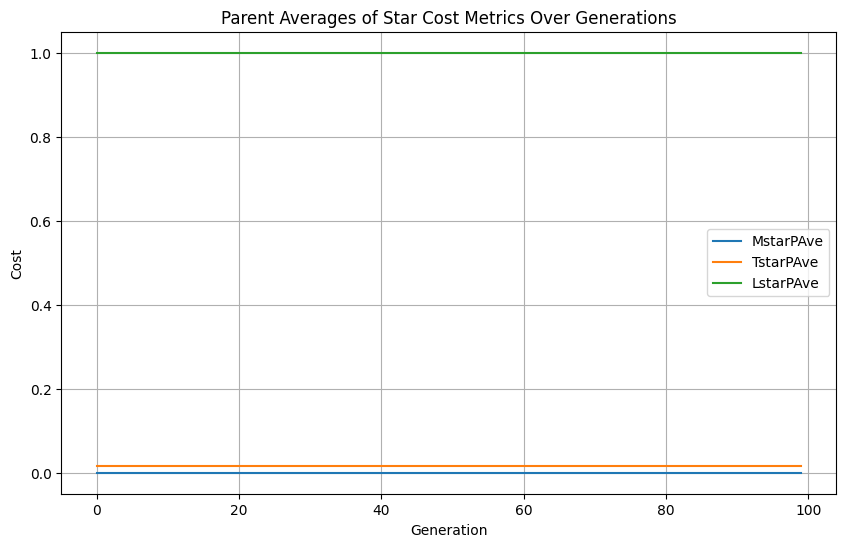

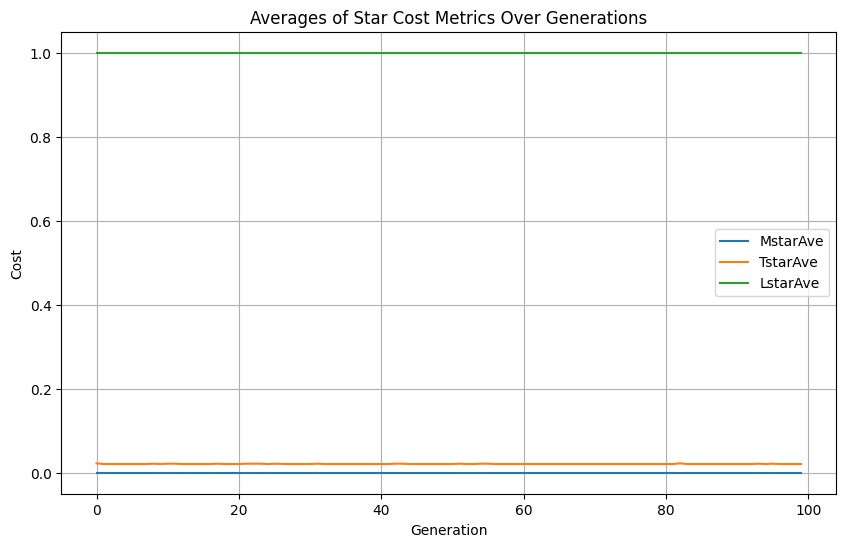

In [13]:
animationObject.plot_star_vals('ga_results.pkl','figures')

## Question 3

In [10]:
for i in range(4):
    res = []
    LAM = data['best_p_strings'][i]
    for j in LAM:
        res.append(float(round(j,3)))
    print(f'Lambda[{i}]: {res}')

    sim = Simulation(parameters=parameters, path_to_genes='')
    PI, _, _, _, _, _, _, _ =  sim.run_simulation(True, LAM)
    print(f'PI[{i}]: {float(round(PI,3))}\n')

Lambda[0]: [0.682, 1.221, 0.571, 0.98, 1.87, 1.124, 2.0, 1.737, 0.731, 1.627, 1.546, 0.965, 1.648, 1.501, 1.133]
PI[0]: 20.167

Lambda[1]: [1.402, 0.146, 1.644, 1.412, 0.163, 0.17, 1.973, 0.749, 0.741, 1.626, 1.894, 1.972, 1.507, 0.753, 0.167]
PI[1]: 20.167

Lambda[2]: [1.981, 0.825, 0.744, 1.553, 0.682, 1.862, 1.717, 0.858, 1.502, 1.509, 0.206, 1.805, 1.011, 1.653, 0.64]
PI[2]: 20.167

Lambda[3]: [0.638, 1.69, 0.047, 1.629, 0.564, 0.236, 1.393, 1.258, 1.755, 1.47, 1.607, 0.564, 0.355, 1.501, 1.614]
PI[3]: 20.167



## Question 5

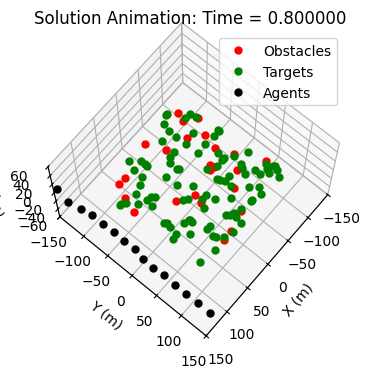

In [14]:
# Save this animation, then take screenshots
animationObject.animation('')